In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import numpy as np
import scipy.stats as stats

import pandas as pd

import matplotlib.pyplot as plt

In [4]:
url = "winequality-white.csv"
data = pd.read_csv(url, sep=";")

#data['boolQuality'] = 0
#data.loc[data['quality'] > 5, 'boolQuality'] = 1

data

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


<Axes: >

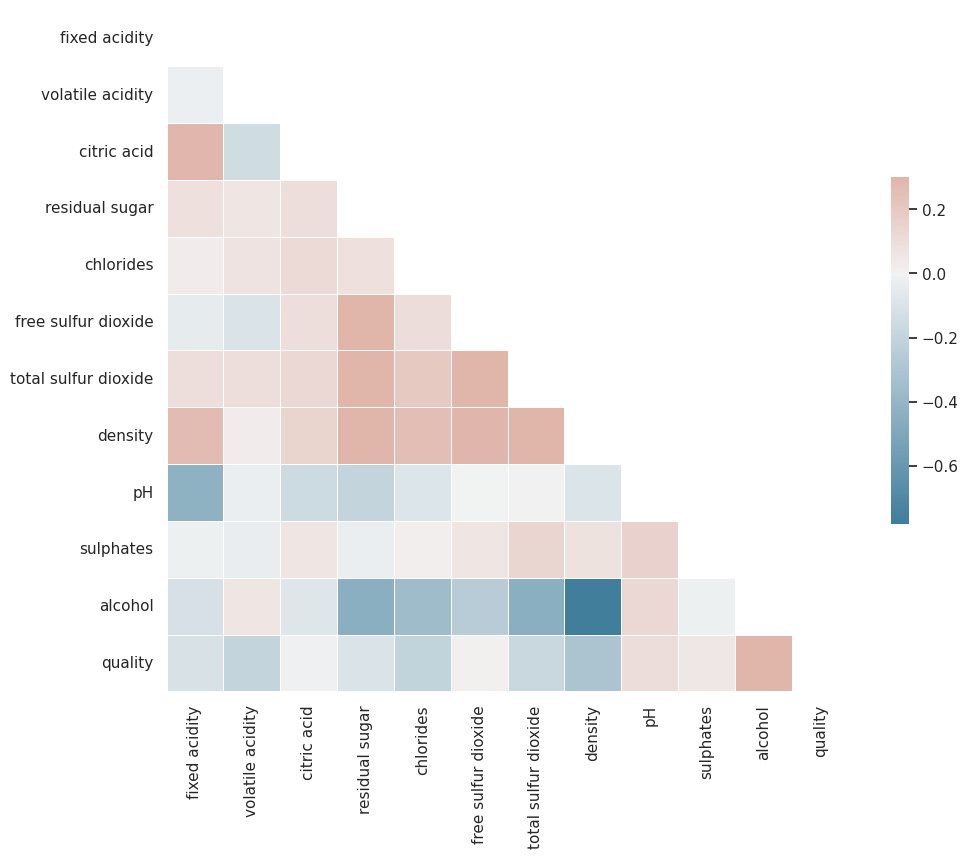

In [5]:
from string import ascii_letters
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

# Compute the correlation matrix
corr = data.corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [6]:
# Divide features and labels
X = data.drop(['residual sugar', 'quality', 'alcohol', 'sulphates', 'pH'], axis=1)
y = data['residual sugar']

# Normalize data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Separate 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, train_size=0.8)

In [7]:
X

,fixed acidity,volatile acidity,citric acid,chlorides,free sulfur dioxide,total sulfur dioxide,density
0,7.0,0.27,0.36,0.045,45.0,170.0,1.00100
1,6.3,0.30,0.34,0.049,14.0,132.0,0.99400
2,8.1,0.28,0.40,0.050,30.0,97.0,0.99510
3,7.2,0.23,0.32,0.058,47.0,186.0,0.99560
4,7.2,0.23,0.32,0.058,47.0,186.0,0.99560
...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,0.039,24.0,92.0,0.99114
4894,6.6,0.32,0.36,0.047,57.0,168.0,0.99490
4895,6.5,0.24,0.19,0.041,30.0,111.0,0.99254
4896,5.5,0.29,0.30,0.022,20.0,110.0,0.98869


In [8]:
y

0       20.7
1        1.6
2        6.9
3        8.5
4        8.5
        ... 
4893     1.6
4894     8.0
4895     1.2
4896     1.1
4897     0.8
Name: residual sugar, Length: 4898, dtype: float64

In [7]:
# Store data into DataLoaders
import torch
from torch.utils.data import TensorDataset, DataLoader

train_data = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32), 
    torch.tensor(y_train.to_numpy(), dtype=torch.float32)
)
test_data = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32), 
    torch.tensor(y_test.to_numpy(), dtype=torch.float32)
)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True, drop_last=True)
test_loader = DataLoader(test_data, batch_size=test_data.tensors[0].shape[0], drop_last=True)

In [8]:
class ANNwine_withBNorm(nn.Module):
    def __init__(self):
        super().__init__()

        self.input = nn.Linear(11, 16) # input

        self.fc1 = nn.Linear(16, 32)
        self.bnorm1 = nn.BatchNorm1d(16) 
        
        self.fc2 = nn.Linear(32, 20)
        self.bnorm2 = nn.BatchNorm1d(32)

        self.output = nn.Linear(20, 1) # output

    def forward(self, x, doBN):

        x = F.relu( self.input(x) )

        if doBN:
            x = self.bnorm1(x)
            x = self.fc1(x)
            x = F.relu(x)

            x = self.bnorm2(x)
            x = self.fc2(x)
            x = F.relu(x)

        else:
            x = F.relu( self.fc1(x) )
            x = F.relu( self.fc2(x) )

        return self.output(x)

In [14]:
numepochs = 1000

def trainTheModel(doBN=True):

    lossfun = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.SGD(winenet.parameters(), lr=0.01)

    losses = torch.zeros(numepochs)
    trainAcc = []
    testAcc = []

    for epochi in range(numepochs):
        winenet.train()

        batchAcc = []
        batchLoss = []
        for X, y in train_loader:

            yHat = winenet(X, doBN)
            loss = lossfun(yHat, y.view(-1,1))

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batchLoss.append(loss.item())
            batchAcc.append( 100*torch.mean(((yHat>0) == y).float()).item() )

        trainAcc.append( np.mean(batchAcc) )
        losses[epochi] = np.mean(batchLoss)

        winenet.eval()
        X, y = next(iter(test_loader))
        with torch.no_grad():
            yHat = winenet(X, doBN)
        testAcc.append( 100*torch.mean(((yHat>0) == y).float()).item() )

    return trainAcc, testAcc, losses

In [ ]:
winenet = ANNwine_withBNorm()
trainAccNo, testAccNo, lossesNo = trainTheModel(False)

winenet = ANNwine_withBNorm()
trainAccWith, testAccWith, lossesWith = trainTheModel(True)

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17,5))

ax[0].plot(lossesWith, label="WITH batchnorm")
ax[0].plot(lossesNo, label="NO batchnorm")
ax[0].set_title("Losses")
ax[0].legend()

ax[1].plot(trainAccWith, label="WITH batchnorm")
ax[1].plot(trainAccNo, label="NO batchnorm")
ax[1].set_title("Train accuracy")
ax[1].legend()

ax[1].plot(testAccWith, label="WITH batchnorm")
ax[1].plot(testAccNo, label="NO batchnorm")
ax[1].set_title("Train accuracy")
ax[1].legend()

plt.show()